In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os as os
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score,roc_auc_score, roc_curve, auc, precision_score, accuracy_score, f1_score, ConfusionMatrixDisplay, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from fairlearn.metrics import MetricFrame, false_positive_rate, false_negative_rate

# Retrieving and Preparing the Data

In [2]:
#check current working directory
cwd = os.getcwd()
print(cwd)
#change working directory to where data is stored if necessary
os.chdir("C:\RMIT Studies\Case Studies\Proj 1\Data")

C:\Users\tariq


In [3]:
#read the data stored on the working directory into a dataframe
df_btc_data = pd.read_csv("BitcoinHeistData.csv") #if data is not stored on the wroking directory then input the address of where data is stored
df_ethereum_data = pd.read_csv("transaction_dataset.csv")
#display all columns when outputting data
pd.set_option('display.max_columns', None)
#verify data has been loaded by checking the head, first 10, values
df_btc_data.head(10)
df_ethereum_data.head(10)

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.000000,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.000000,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.050000,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.000000,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.000000,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
5,5,6,0x000895ad78f4403ecd9468900e68d6ee506136fd,0,9900.12,375.48,20926.68,2,3,0,2,1,0.724148,4.813776,3.234908,4.166800,5.536916,4.851858,0.0,0.0,0.0,5,9.703716,9.704724,0.0,0.001008,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
6,6,7,0x000d63fc5df52b0204374c2f5a3249779805d5d1,0,69.46,629.44,8660.35,25,11,0,9,20,0.049000,2.650000,1.098115,0.009457,4.284785,0.482496,0.0,0.0,0.0,36,12.062394,12.079266,0.0,0.016872,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
7,7,8,0x000e001ab444fa8d6dc4a402f8d7cfc88fe8c64d,0,1497.39,176.84,319828.05,213,5,0,3,3,0.118490,2.000000,0.891098,0.000000,0.700000,0.040861,0.0,0.0,0.0,218,8.703392,4.455490,0.0,-4.247902,7.0,3.979520e+02,0.000000e+00,0.0,0.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,56.850281,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,

In [4]:
#check observations and variables of the data
print("The shape of bitcoin dataset (rows by columns) is: ", df_btc_data.shape)
print("The shape of ethereum  dataset (rows by columns) is: ", df_ethereum_data.shape)

#check column names
print("The columns of bitcoin dataset are: \n",  df_btc_data.columns
)
print("The columns of ethereum dataset are: \n",  df_ethereum_data.columns)


The shape of bitcoin dataset (rows by columns) is:  (2916697, 10)
The shape of ethereum  dataset (rows by columns) is:  (9841, 51)
The columns of bitcoin dataset are: 
 Index(['address', 'year', 'day', 'length', 'weight', 'count', 'looped',
       'neighbors', 'income', 'label'],
      dtype='object')
The columns of ethereum dataset are: 
 Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether s

In [5]:
#standardise column names- btc already standardised
df_btc_data.columns = df_btc_data.columns.str.replace(" ", "_").str.replace('(',"").str.replace(')',"").str.replace("'",'').str.strip().str.lower()
df_ethereum_data.columns = df_ethereum_data.columns.str.replace(" ", "_").str.replace('(',"").str.replace(')',"").str.replace("'",'').str.strip().str.lower()
#drop unnamed column identifier
df_ethereum_data = df_ethereum_data.drop(columns='unnamed:_0', errors='ignore')

#remove trailing underscore
remove_trailing_underscore = df_ethereum_data.iloc[:, 25:50]
remove_trailing_underscore.columns = remove_trailing_underscore.columns.str.replace(r'(^_)', '',regex = True)
remove_trailing_underscore.columns
df_ethereum_data.columns.values[25:50] = remove_trailing_underscore.columns

In [6]:
#check information about data
print("BTC starts here: \n")
df_btc_data.info()

print("\nEthereum starts here: \n")
df_ethereum_data.info()
#etherneum seems to have some missing values

BTC starts here: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2916697 entries, 0 to 2916696
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   address    object 
 1   year       int64  
 2   day        int64  
 3   length     int64  
 4   weight     float64
 5   count      int64  
 6   looped     int64  
 7   neighbors  int64  
 8   income     float64
 9   label      object 
dtypes: float64(2), int64(6), object(2)
memory usage: 222.5+ MB

Ethereum starts here: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 50 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   index                                                9841 non-null   int64  
 1   address                                              9841 non-null   object 
 2   flag                                               

In [7]:
#analyze descritpive statistics for variables; check if no sentinel missing values, extreme outliers, incorrect input data or other errors
print("BTC starts here: \n")
print(df_btc_data.describe())
print("\nEthereum starts here: \n")
print(df_ethereum_data.describe())

BTC starts here: 

               year           day        length        weight         count  \
count  2.916697e+06  2.916697e+06  2.916697e+06  2.916697e+06  2.916697e+06   
mean   2.014475e+03  1.814572e+02  4.500859e+01  5.455192e-01  7.216446e+02   
std    2.257398e+00  1.040118e+02  5.898236e+01  3.674255e+00  1.689676e+03   
min    2.011000e+03  1.000000e+00  0.000000e+00  3.606469e-94  1.000000e+00   
25%    2.013000e+03  9.200000e+01  2.000000e+00  2.148438e-02  1.000000e+00   
50%    2.014000e+03  1.810000e+02  8.000000e+00  2.500000e-01  1.000000e+00   
75%    2.016000e+03  2.710000e+02  1.080000e+02  8.819482e-01  5.600000e+01   
max    2.018000e+03  3.650000e+02  1.440000e+02  1.943749e+03  1.449700e+04   

             looped     neighbors        income  
count  2.916697e+06  2.916697e+06  2.916697e+06  
mean   2.385067e+02  2.206516e+00  4.464889e+09  
std    9.663217e+02  1.791877e+01  1.626860e+11  
min    0.000000e+00  1.000000e+00  3.000000e+07  
25%    0.000000e+00

In [8]:
#confirm there are no duplicates
print("BTC starts here: \n")
print(df_btc_data.duplicated().sum())
df_btc_data.isnull().sum()

#check for missing values
print("\nEthereum starts here: \n")
print(df_ethereum_data.duplicated().sum())
df_ethereum_data.isnull().sum()

BTC starts here: 

0

Ethereum starts here: 

0


index                                                     0
address                                                   0
flag                                                      0
avg_min_between_sent_tnx                                  0
avg_min_between_received_tnx                              0
time_diff_between_first_and_last_mins                     0
sent_tnx                                                  0
received_tnx                                              0
number_of_created_contracts                               0
unique_received_from_addresses                            0
unique_sent_to_addresses                                  0
min_value_received                                        0
max_value_received_                                       0
avg_val_received                                          0
min_val_sent                                              0
max_val_sent                                              0
avg_val_sent                            

In [9]:
#confirm there are no duplicates
print("BTC starts here: \n")
print(df_btc_data.duplicated().sum())
df_btc_data.isnull().sum()

#check for missing values
print("\nEthereum starts here: \n")
print(df_ethereum_data.duplicated().sum())
df_ethereum_data.isnull().sum()

BTC starts here: 

0

Ethereum starts here: 

0


index                                                     0
address                                                   0
flag                                                      0
avg_min_between_sent_tnx                                  0
avg_min_between_received_tnx                              0
time_diff_between_first_and_last_mins                     0
sent_tnx                                                  0
received_tnx                                              0
number_of_created_contracts                               0
unique_received_from_addresses                            0
unique_sent_to_addresses                                  0
min_value_received                                        0
max_value_received_                                       0
avg_val_received                                          0
min_val_sent                                              0
max_val_sent                                              0
avg_val_sent                            

In [10]:
df_ethereum_null = df_ethereum_data[df_ethereum_data.isnull().any(axis=1)]
#an analysis of missing values finds that missing values conform to those accounts which have never sent or received tokens
df_ethereum_null.head()

#fill with 0
df_ethereum_data = df_ethereum_data.fillna(0)

In [11]:
df_ethereum_data.isna().sum()

index                                                  0
address                                                0
flag                                                   0
avg_min_between_sent_tnx                               0
avg_min_between_received_tnx                           0
time_diff_between_first_and_last_mins                  0
sent_tnx                                               0
received_tnx                                           0
number_of_created_contracts                            0
unique_received_from_addresses                         0
unique_sent_to_addresses                               0
min_value_received                                     0
max_value_received_                                    0
avg_val_received                                       0
min_val_sent                                           0
max_val_sent                                           0
avg_val_sent                                           0
min_value_sent_to_contract     

In [12]:
#drop unimportant columns
df_ethereum_data = df_ethereum_data.drop(columns=['index', 'address'], errors='ignore')
df_ethereum_data.head()

df_btc_data = df_btc_data.drop(columns=['address'], errors='ignore')
df_btc_data.head()

,year,day,length,weight,count,looped,neighbors,income,label
0,2017,11,18,0.008333,1,0,2,100050000.0,princetonCerber
1,2016,132,44,0.000244,1,0,1,100000000.0,princetonLocky
2,2016,246,0,1.000000,1,0,2,200000000.0,princetonCerber
3,2016,322,72,0.003906,1,0,2,71200000.0,princetonCerber
4,2016,238,144,0.072848,456,0,1,200000000.0,princetonLocky


In [13]:
#edit btc labels
if df_btc_data['label'].nunique() > 2:
    df_btc_data_full_label = df_btc_data['label']
    df_btc_data['label'] = np.where(df_btc_data['label'] == 'white', 0, 1)
df_btc_data['label'].unique()

#remove most received and sent token as encoding them will introduce multiple columns and complexity
df_ethereum_data = df_ethereum_data.drop(columns=['erc20_most_sent_token_type', 'erc20_most_rec_token_type'], errors='ignore')

# Modelling and Processing Data

In [18]:
#sample and divide for btc
df_btc_sample, _ = train_test_split(df_btc_data, train_size = 400000, stratify= df_btc_data['label'], random_state=42)

print("BTC original class distribution")
print(df_btc_data['label'].value_counts())
print(df_btc_data['label'].value_counts(normalize=True))

print("BTC stratified class distribution")
print(df_btc_sample['label'].value_counts())
print(df_btc_sample['label'].value_counts(normalize=True))

btc_numeric_columns = df_btc_data.select_dtypes(include=np.number).columns

btc_sample_comparision = pd.DataFrame({ "Original dataset mean": df_btc_data[btc_numeric_columns].mean(),
                                        'Original dataset STD': df_btc_data[btc_numeric_columns].std(),
                                        'Sample dataset mean': df_btc_sample[btc_numeric_columns].mean(),
                                        "Sample dataset STD": df_btc_sample[btc_numeric_columns].std()})


print("BTC sample comparision")
print(btc_sample_comparision)

y_btc = df_btc_sample['label']
X_btc = df_btc_sample.drop("label", axis=1)

# divide classification target for ethereum
y_eth = df_ethereum_data["flag"]
X_eth = df_ethereum_data.drop("flag", axis=1)

BTC original class distribution
label
0    2875284
1      41413
Name: count, dtype: int64
label
0    0.985801
1    0.014199
Name: proportion, dtype: float64
BTC stratified class distribution
label
0    394321
1      5679
Name: count, dtype: int64
label
0    0.985803
1    0.014198
Name: proportion, dtype: float64
BTC sample comparision
           Original dataset mean  Original dataset STD  Sample dataset mean  \
year                2.014475e+03          2.257398e+00         2.014477e+03   
day                 1.814572e+02          1.040118e+02         1.814332e+02   
length              4.500859e+01          5.898236e+01         4.500863e+01   
weight              5.455192e-01          3.674255e+00         5.526731e-01   
count               7.216446e+02          1.689676e+03         7.234904e+02   
looped              2.385067e+02          9.663217e+02         2.386501e+02   
neighbors           2.206516e+00          1.791877e+01         2.240730e+00   
income              4.464889e+0

In [16]:
#train-test split stratified because classes are severely unbalanced
X_btc_train, X_btc_test, y_btc_train, y_btc_test, year_btc_train, year_btc_test = train_test_split(X_btc.values, y_btc.values, df_btc_sample['year'].values, test_size=0.25,
                                                    stratify =y_btc, random_state=42)
X_eth_train, X_eth_test, y_eth_train, y_eth_test = train_test_split(X_eth.values, y_eth.values, test_size=0.25,
                                                    stratify =y_eth, random_state=42)
print("BTC \n: ", X_btc_train.shape, y_btc_train.shape)
print("Ethereum \n: ", X_eth_train.shape, y_eth_train.shape)

#check y classes divide
print("BTC \n: ", y_btc.value_counts())
print("Ethereum \n: ", y_eth.value_counts())

BTC 
:  (300000, 8) (300000,)
Ethereum 
:  (7380, 45) (7380,)
BTC 
:  label
0    394321
1      5679
Name: count, dtype: int64
Ethereum 
:  flag
0    7662
1    2179
Name: count, dtype: int64


## Classifier 1: Random Forest

In [17]:
#hyper parameters range for random forest
param_distribution = {
    'n_estimators': randint(100,500),
    'max_depth': randint(2, 25),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

#build and run random forest classifier
rf = RandomForestClassifier(random_state=42, class_weight = 'balanced', n_jobs=-1)

rand_search_btc = RandomizedSearchCV(
  rf, param_distributions=param_distribution,
  n_iter=10, cv=5, scoring='f1',
  n_jobs=-1, random_state=42)

rand_search_btc.fit(X_btc_train, y_btc_train)

rand_search_eth = RandomizedSearchCV(
  rf, param_distributions=param_distribution,
  n_iter=10, cv=5, scoring='f1',
  n_jobs=-1, random_state=42)

rand_search_eth.fit(X_eth_train, y_eth_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....002207D3C39D0>, 'min_samples_leaf': <scipy.stats....002207D3EBBB0>, 'min_samples_split': <scipy.stats....002207D3C3C50>, 'n_estimators': <scipy.stats....002207D35F8C0>}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [19]:
#Analysis

print("BTC best params and scores")
print(rand_search_btc.best_params_)
print(rand_search_btc.best_score_)

print("Eth best params and scores")
print(rand_search_eth.best_params_)
print(rand_search_eth.best_score_)

print("Analyse cross validation differences")
btc_cv_results = pd.DataFrame(rand_search_btc.cv_results_)
eth_cv_results = pd.DataFrame(rand_search_eth.cv_results_)

btc_cv_results.sort_values(by="mean_test_score", ascending=False).head()
eth_cv_results.sort_values(by="mean_test_score", ascending=False).head()


BTC best params and scores
{'max_depth': 23, 'min_samples_leaf': 9, 'min_samples_split': 18, 'n_estimators': 158}
0.2874027414520334
Eth best params and scores
{'max_depth': 22, 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}
0.9040216000069288
Analyse cross validation differences


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,11.642092,0.424292,1.375692,0.452036,22,1,13,413,"{'max_depth': 22, 'min_samples_leaf': 1, 'min_...",0.907956,0.890650,0.894652,0.911111,0.915739,0.904022,0.009692,1
3,5.482889,0.260109,0.807252,0.317216,22,4,9,251,"{'max_depth': 22, 'min_samples_leaf': 4, 'min_...",0.902326,0.885400,0.899522,0.911950,0.917460,0.903331,0.011054,2
5,6.619183,0.192531,1.128312,0.170508,13,6,3,291,"{'max_depth': 13, 'min_samples_leaf': 6, 'min_...",0.903226,0.875957,0.902208,0.898279,0.915094,0.898953,0.012796,3
8,3.696853,0.615203,0.754711,0.271265,11,3,13,154,"{'max_depth': 11, 'min_samples_leaf': 3, 'min_...",0.889922,0.884438,0.896989,0.906250,0.912226,0.897965,0.010204,4
2,3.702248,0.809895,0.691642,0.296543,20,7,12,187,"{'max_depth': 20, 'min_samples_leaf': 7, 'min_...",0.899083,0.871017,0.901099,0.898911,0.914463,0.896915,0.014176,5


In [20]:
y_btc_pred_rf = rand_search_btc.predict(X_btc_test)
y_eth_pred_rf = rand_search_eth.predict(X_eth_test)

y_pred_btc_proba_rf = rand_search_btc.predict_proba(X_btc_test)[:, 1]
y_pred_eth_proba_rf = rand_search_eth.predict_proba(X_eth_test)[:, 1]

## Classifier 2: Logistic Regression

In [21]:
#scale values for Logistic Regression to properly apply logistic regression
scaler_btc = StandardScaler()
X_train_scaled_btc = scaler_btc.fit_transform(X_btc_train)
X_test_scaled_btc = scaler_btc.transform(X_btc_test)

scaler_eth = StandardScaler()
X_train_scaled_eth = scaler_eth.fit_transform(X_eth_train)
X_test_scaled_eth = scaler_eth.transform(X_eth_test)

In [22]:
# build and run logistic regression classifier
lr_classifier_btc = LogisticRegression(max_iter= 1000, class_weight='balanced', random_state=42, n_jobs = -1)
lr_classifier_eth = LogisticRegression(max_iter= 1000, class_weight='balanced', random_state=42, n_jobs = -1)

lr_classifier_btc.fit(X_train_scaled_btc, y_btc_train)
lr_classifier_eth.fit(X_train_scaled_eth, y_eth_train)

#make predictions on the test set.
y_btc_pred_lr = lr_classifier_btc.predict(X_test_scaled_btc)
y_eth_pred_lr = lr_classifier_eth.predict(X_test_scaled_eth)


y_pred_btc_proba_lr = lr_classifier_btc.predict_proba(X_test_scaled_btc)[:, 1]
y_pred_eth_proba_lr = lr_classifier_eth.predict_proba(X_test_scaled_eth)[:, 1]

In [23]:
#get evaluation metrics

def get_metrics(y_true_value, y_predicted_value, y_probability):
    tn, fp, fn, tp = confusion_matrix(y_true_value, y_predicted_value).ravel()
    print("Confusion Matrix: ", confusion_matrix(y_true_value, y_predicted_value))
    print("ROC AUC curve: ", roc_auc_score(y_true_value, y_probability))
    print("Precision Score: ", precision_score(y_true_value, y_predicted_value))
    print("Recall Score: ", recall_score(y_true_value, y_predicted_value))
    print("Accuracy Score: ", accuracy_score(y_true_value, y_predicted_value))
    print("F1 Score: ", f1_score(y_true_value, y_predicted_value))
    print("False Positive Rate: ", fp / (fp + tn))
    print("False Negative Rate: ", fn / (fn + tp))

print("Random Forest BTC: \n") 
get_metrics(y_btc_test, y_btc_pred_rf, y_pred_btc_proba_rf)

print("Random Forest Ethereum: \n") 
get_metrics(y_eth_test, y_eth_pred_rf, y_pred_eth_proba_rf)

print("Logistic Regression BTC: \n") 
get_metrics(y_btc_test, y_btc_pred_lr, y_pred_btc_proba_lr)

print("Logistic Regression Ethereum: \n") 
get_metrics(y_eth_test, y_eth_pred_lr, y_pred_eth_proba_lr)

Random Forest BTC: 

Confusion Matrix:  [[94877  3703]
 [  581   839]]
ROC AUC curve:  0.9350428514483125
Precision Score:  0.18472038749449582
Recall Score:  0.5908450704225352
Accuracy Score:  0.95716
F1 Score:  0.2814491781281449
False Positive Rate:  0.03756340028403327
False Negative Rate:  0.4091549295774648
Random Forest Ethereum: 

Confusion Matrix:  [[1889   27]
 [  77  468]]
ROC AUC curve:  0.9891162781789279
Precision Score:  0.9454545454545454
Recall Score:  0.8587155963302753
Accuracy Score:  0.9577407557903291
F1 Score:  0.9
False Positive Rate:  0.014091858037578288
False Negative Rate:  0.14128440366972478
Logistic Regression BTC: 

Confusion Matrix:  [[52413 46167]
 [  414  1006]]
ROC AUC curve:  0.6077614306247303
Precision Score:  0.021325758378733597
Recall Score:  0.7084507042253522
Accuracy Score:  0.53419
F1 Score:  0.04140514065811948
False Positive Rate:  0.46832014607425443
False Negative Rate:  0.2915492957746479
Logistic Regression Ethereum: 

Confusion Matr

BTC Random Forest Confucian Matrix: 
Ethereum Random Forest Confucian Matrix: 
BTC Logistic Regression Confucian Matrix: 
Etereum Logistic Regression Confucian Matrix: 


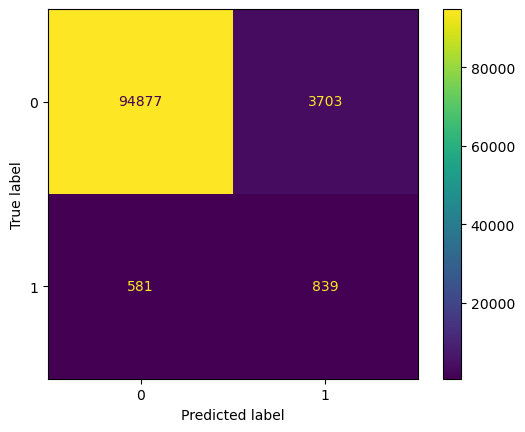

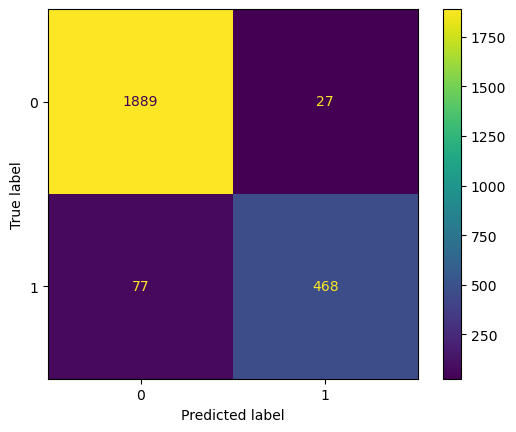

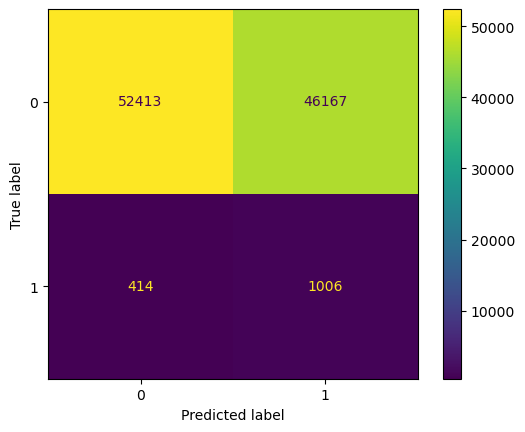

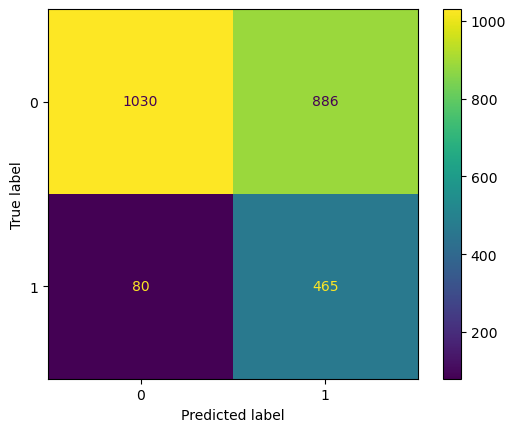

In [24]:
#visualize confucian matrix
def build_confucian_matrix(y_true_value, y_predicted_value):
    cm = confusion_matrix(y_true_value, y_predicted_value)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot();

print("BTC Random Forest Confucian Matrix: ")
build_confucian_matrix(y_btc_test, y_btc_pred_rf)

print("Ethereum Random Forest Confucian Matrix: ")
build_confucian_matrix(y_eth_test, y_eth_pred_rf)

print("BTC Logistic Regression Confucian Matrix: ")
build_confucian_matrix(y_btc_test, y_btc_pred_lr)

print("Etereum Logistic Regression Confucian Matrix: ")
build_confucian_matrix(y_eth_test, y_eth_pred_lr)

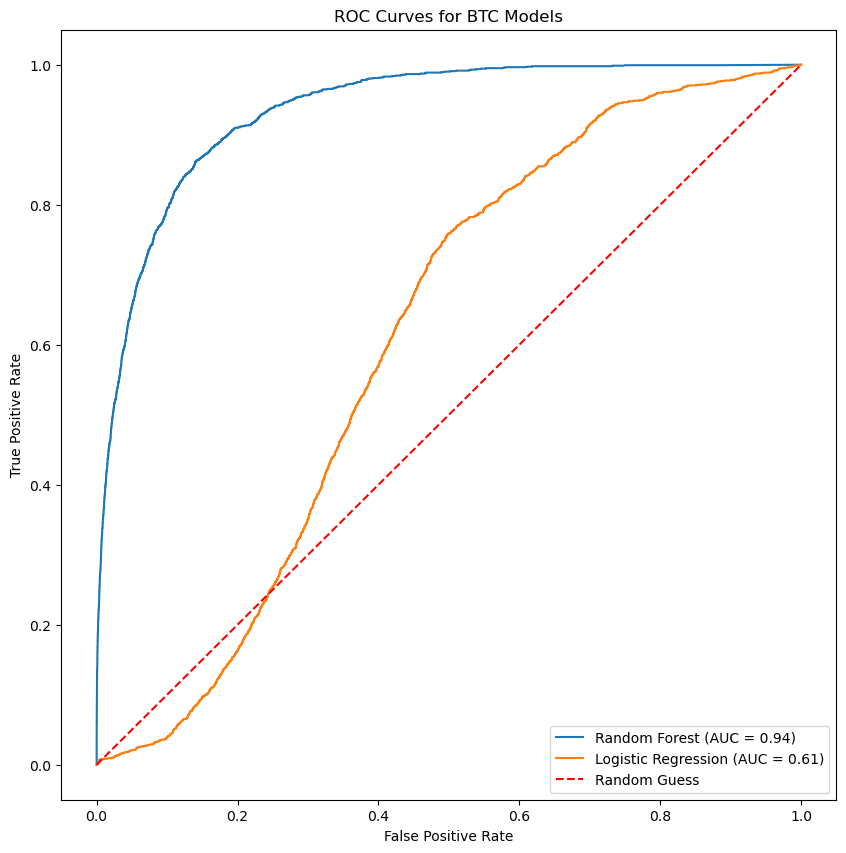

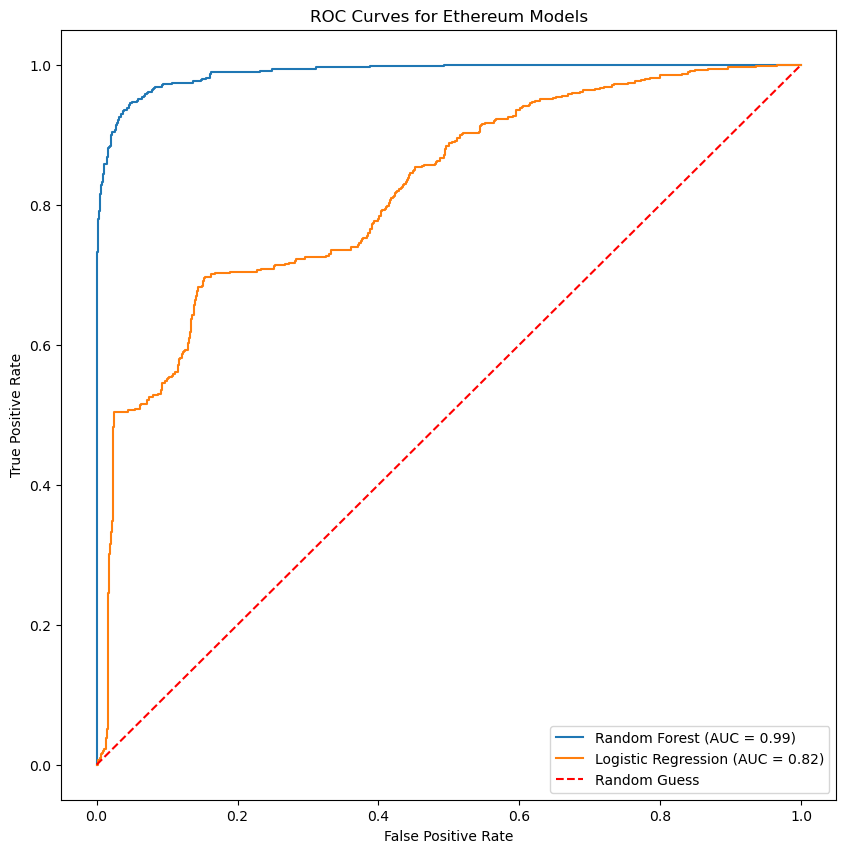

In [25]:
# build roc graphs
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)

test_btc_df = pd.DataFrame(
    {'True': y_btc_test, 'RandomForest': y_pred_btc_proba_rf, 'LogisticRegression': y_pred_btc_proba_lr})

fpr_rf, tpr_rf, _ = roc_curve(test_btc_df['True'], test_btc_df['RandomForest'])
auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, _ = roc_curve(test_btc_df['True'], test_btc_df['LogisticRegression'])
auc_lr = auc(fpr_lr, tpr_lr)

ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')

ax.set_title('ROC Curves for BTC Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

test_ethereum_df = pd.DataFrame(
    {'True': y_eth_test, 'RandomForest': y_pred_eth_proba_rf, 'LogisticRegression': y_pred_eth_proba_lr})
fig, ax =plt.subplots(1, 1)
fig.set_size_inches(10, 10)

fpr_rf, tpr_rf, _ = roc_curve(test_ethereum_df['True'], test_ethereum_df['RandomForest'])
auc_rf = auc(fpr_rf, tpr_rf)
fpr_lr, tpr_lr, _ =roc_curve(test_ethereum_df['True'], test_ethereum_df['LogisticRegression'])
auc_lr = auc(fpr_lr, tpr_lr)

ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')

ax.set_title('ROC Curves for Ethereum Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

In [28]:
#insights onto what features models found informative
best_rf_btc = rand_search_btc.best_estimator_
best_rf_eth =rand_search_eth.best_estimator_

rf_importances_btc = pd.Series(best_rf_btc.feature_importances_, index=X_btc.columns).head(8)
print("\n BTC RF: \n", rf_importances_btc.sort_values(ascending=False))

rf_importances_eth = pd.Series(best_rf_eth.feature_importances_, index=X_eth.columns).head(10)
print("\n Etheum RF: \n", rf_importances_eth.sort_values(ascending=False))

lr_importances_btc = pd.Series(lr_classifier_btc.coef_[0], index=X_btc.columns).head(8)
print("\n BTC LR: \n", lr_importances_btc.sort_values(ascending=False))

lr_importances_eth = pd.Series(lr_classifier_eth.coef_[0], index=X_eth.columns).head(10)
print("\n Ethereum LR: \n", lr_importances_eth.sort_values(ascending=False))


 BTC RF: 
 year         0.343698
income       0.216074
day          0.160021
weight       0.095328
count        0.053372
neighbors    0.050659
length       0.049897
looped       0.030952
dtype: float64

 Etheum RF: 
 time_diff_between_first_and_last_mins    0.106644
avg_min_between_received_tnx             0.067718
unique_received_from_addresses           0.067040
max_value_received_                      0.056986
min_value_received                       0.043165
received_tnx                             0.032561
avg_min_between_sent_tnx                 0.031990
sent_tnx                                 0.026982
unique_sent_to_addresses                 0.008941
number_of_created_contracts              0.006420
dtype: float64

 BTC LR: 
 weight       0.524397
year         0.239796
length       0.037153
day         -0.068112
count       -0.092173
neighbors   -0.200999
looped      -0.241452
income      -7.219496
dtype: float64

 Ethereum LR: 
 unique_received_from_addresses           0.6055

In [27]:
# Learning curves
#BTC
btc_rf_train_sizes, btc_rf_train_scores, btc_rf_validation_scores = learning_curve(rand_search_btc.best_estimator_,
                                                                                   X_btc_train,
                                                                                   y_btc_train,
                                                                                   train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0],
                                                                                   cv=5,
                                                                                   scoring = 'f1',
                                                                                   n_jobs= -1
)

#Eth
eth_rf_train_sizes, eth_rf_train_scores, eth_rf_validation_scores = learning_curve(rand_search_eth.best_estimator_,
                                                                                   X_eth_train,
                                                                                   y_eth_train,
                                                                                   train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0],
                                                                                   cv=5,
                                                                                   scoring = 'f1',
                                                                                   n_jobs= -1
)




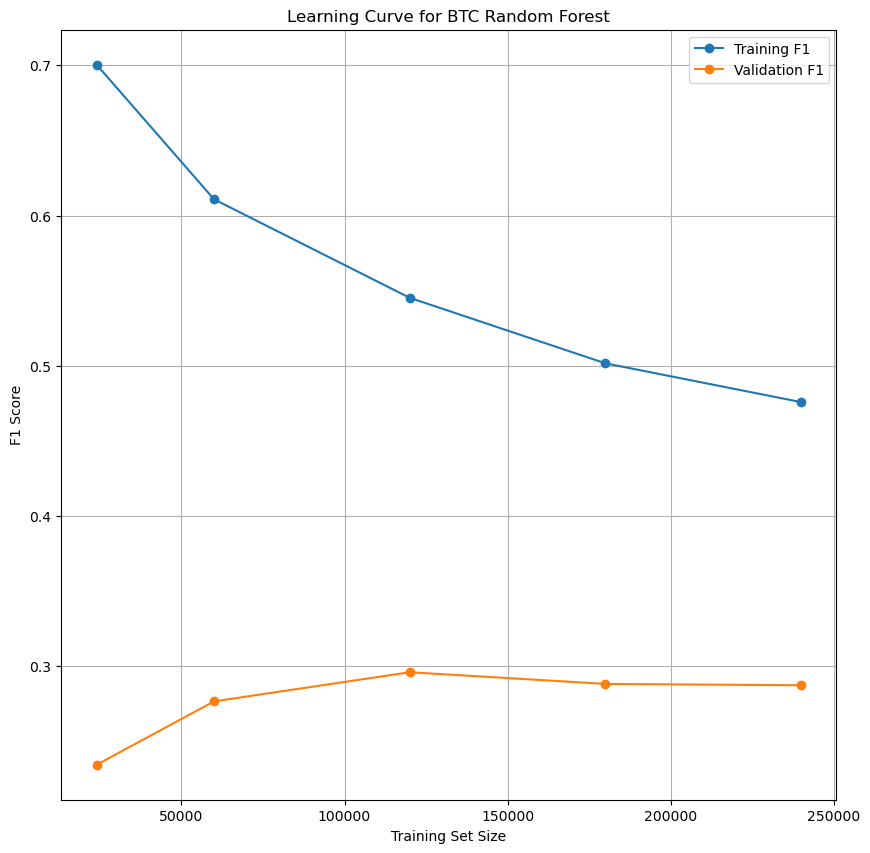

In [29]:
btc_rf_train_mean = btc_rf_train_scores.mean(axis=1)
btc_rf_validation_mean = btc_rf_validation_scores.mean(axis=1)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)

ax.plot(
    btc_rf_train_sizes,
    btc_rf_train_mean,
    marker='o',
    label='Training F1'
)

ax.plot(
    btc_rf_train_sizes,
    btc_rf_validation_mean,
    marker='o',
    label='Validation F1'
)

ax.set_title("Learning Curve for BTC Random Forest")
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid()


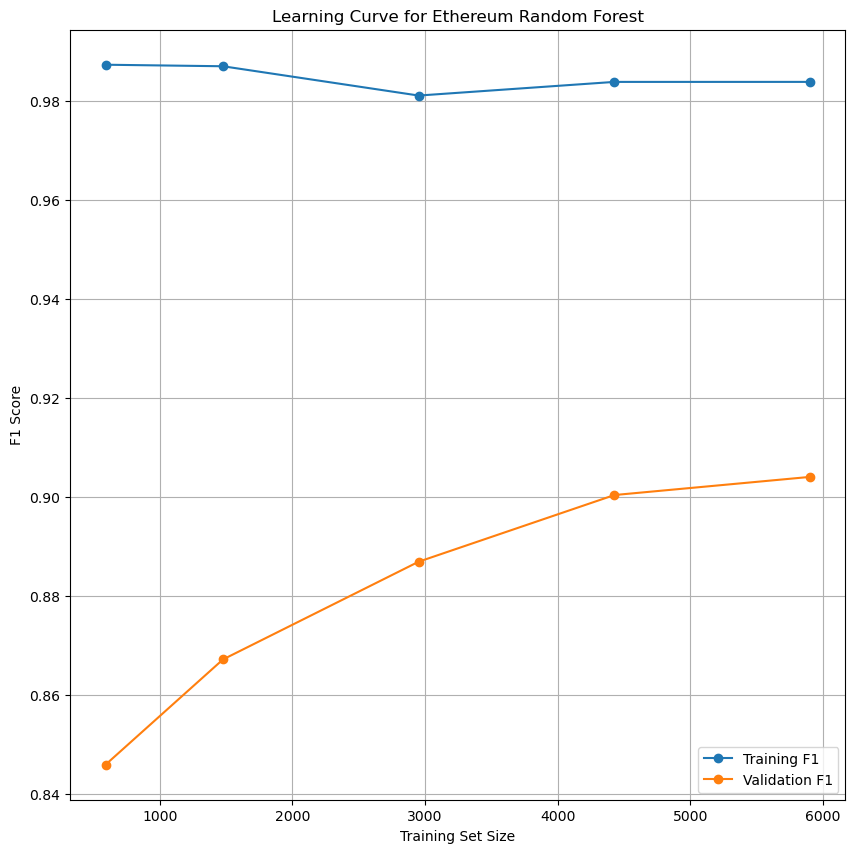

In [30]:
eth_rf_train_mean = eth_rf_train_scores.mean(axis=1)
eth_rf_validation_mean = eth_rf_validation_scores.mean(axis=1)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)

ax.plot(
    eth_rf_train_sizes,
    eth_rf_train_mean,
    marker='o',
    label='Training F1'
)

ax.plot(
    eth_rf_train_sizes,
    eth_rf_validation_mean,
    marker='o',
    label='Validation F1'
)

ax.set_title("Learning Curve for Ethereum Random Forest")
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid()

In [31]:
#BTC
btc_lr_train_sizes, btc_lr_train_scores, btc_lr_validation_scores = learning_curve(lr_classifier_btc,
                                                                                   X_train_scaled_btc,
                                                                                   y_btc_train,
                                                                                   train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0],
                                                                                   cv=5,
                                                                                   scoring = 'f1',
                                                                                   n_jobs= -1
)

#Eth
eth_lr_train_sizes, eth_lr_train_scores, eth_lr_validation_scores = learning_curve(lr_classifier_eth,
                                                                                   X_train_scaled_eth,
                                                                                   y_eth_train,
                                                                                   train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0],
                                                                                   cv=5,
                                                                                   scoring = 'f1',
                                                                                   n_jobs= -1
)

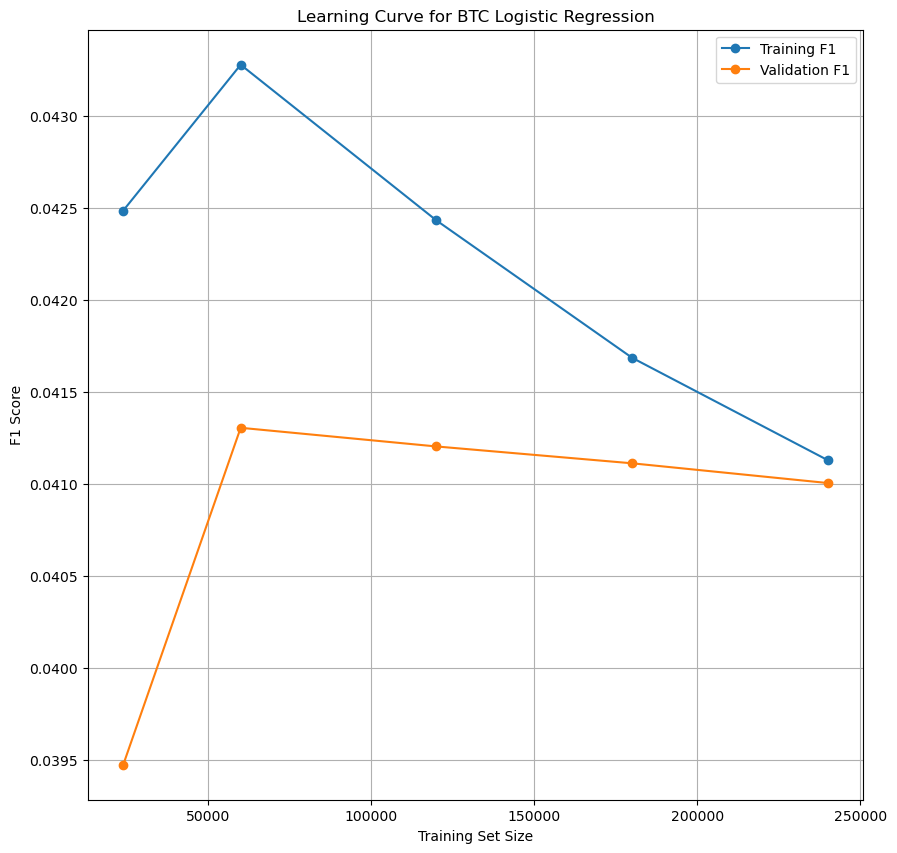

In [32]:
btc_lr_train_mean = btc_lr_train_scores.mean(axis=1)
btc_lr_validation_mean = btc_lr_validation_scores.mean(axis=1)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)

ax.plot(
    btc_lr_train_sizes,
    btc_lr_train_mean,
    marker='o',
    label='Training F1'
)

ax.plot(
    btc_lr_train_sizes,
    btc_lr_validation_mean,
    marker='o',
    label='Validation F1'
)

ax.set_title('Learning Curve for BTC Logistic Regression')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid()


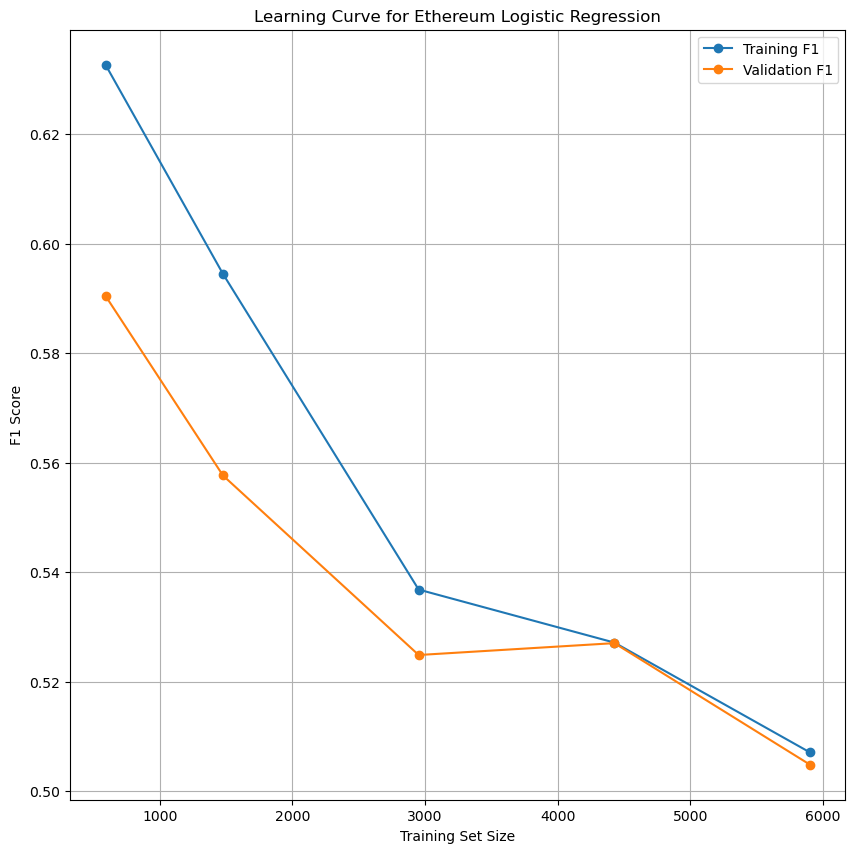

In [33]:
eth_lr_train_mean = eth_lr_train_scores.mean(axis=1)
eth_lr_validation_mean = eth_lr_validation_scores.mean(axis=1)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)

ax.plot(
    eth_lr_train_sizes,
    eth_lr_train_mean,
    marker='o',
    label='Training F1'
)

ax.plot(
    eth_lr_train_sizes,
    eth_lr_validation_mean,
    marker='o',
    label='Validation F1'
)

ax.set_title('Learning Curve for Ethereum Logistic Regression')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid()

In [34]:
btc_year_groups = pd.cut(year_btc_test,
                         bins = [2008, 2012, 2015, 2018],
                         labels = ["2009-2012", "2013-2015", "2016-2018"])

In [45]:
btc_metrics = {
    "accuracy": accuracy_score,
    "precision": precision_score,
    "false positive rate": false_positive_rate,
    "false negative rate": false_negative_rate,
    "recall": recall_score,
    "f1": f1_score
}

btc_fairness = MetricFrame(metrics=btc_metrics,
                           y_true=y_btc_test,
                           y_pred=y_btc_pred_rf,
                           sensitive_features=btc_year_groups
)

print("Overall performance");
print(btc_fairness.overall)

print("Performance by year");
print(btc_fairness.by_group)

print("Difference in performance")
print(btc_fairness.difference())

print("amount in each year")
group_counts = pd.Series(btc_year_groups).value_counts().sort_index()
print(group_counts)

print("amount fraudulent in each year")
group_fraudulent = pd.Series(btc_year_groups[y_btc_test == 1]).value_counts().sort_index()
print(group_fraudulent)

Overall performance
accuracy               0.957160
precision              0.184720
false positive rate    0.037563
false negative rate    0.409155
recall                 0.590845
f1                     0.281449
dtype: float64
Performance by year
                     accuracy  precision  false positive rate  \
sensitive_feature_0                                             
2009-2012            0.998827   0.000000             0.000040   
2013-2015            0.941180   0.159766             0.049981   
2016-2018            0.945811   0.208711             0.050245   

                     false negative rate    recall        f1  
sensitive_feature_0                                           
2009-2012                       1.000000  0.000000  0.000000  
2013-2015                       0.512363  0.487637  0.240678  
2016-2018                       0.271084  0.728916  0.324506  
Difference in performance
accuracy               0.057648
precision              0.208711
false positive rate   

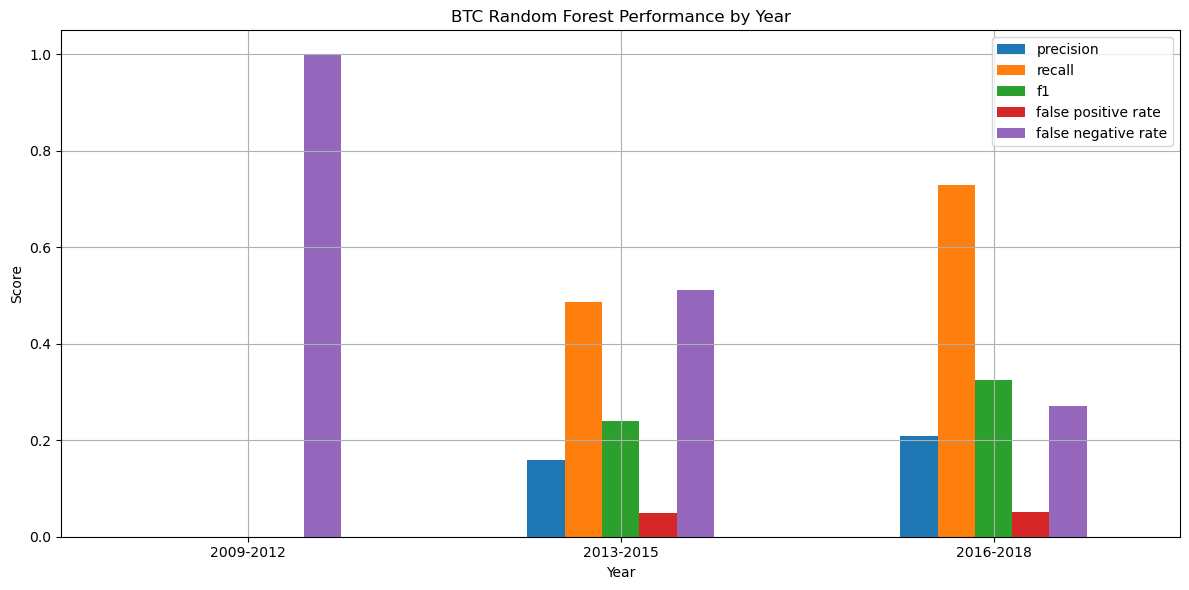

In [38]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(12, 6)

btc_fairness.by_group[["precision", "recall", "f1", "false positive rate", "false negative rate"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("BTC Random Forest Performance by Year")
ax.set_ylabel("Score")
ax.set_xlabel("Year")
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [39]:
btc_fairness_lr = MetricFrame(metrics=btc_metrics,
                           y_true=y_btc_test,
                           y_pred=y_btc_pred_lr,
                           sensitive_features=btc_year_groups
)

print("Overall performance");
print(btc_fairness_lr.overall)

print("Performance by year");
print(btc_fairness_lr.by_group)

print("Difference in performance")
print(btc_fairness_lr.difference())

Overall performance
accuracy               0.534190
precision              0.021326
false positive rate    0.468320
false negative rate    0.291549
recall                 0.708451
f1                     0.041405
dtype: float64
Performance by year
                     accuracy  precision  false positive rate  \
sensitive_feature_0                                             
2009-2012            0.991267   0.000000             0.007610   
2013-2015            0.629247   0.026987             0.368716   
2016-2018            0.132822   0.019007             0.881849   

                     false negative rate    recall        f1  
sensitive_feature_0                                           
2009-2012                       1.000000  0.000000  0.000000  
2013-2015                       0.475275  0.524725  0.051334  
2016-2018                       0.060241  0.939759  0.037260  
Difference in performance
accuracy               0.858444
precision              0.026987
false positive rate   

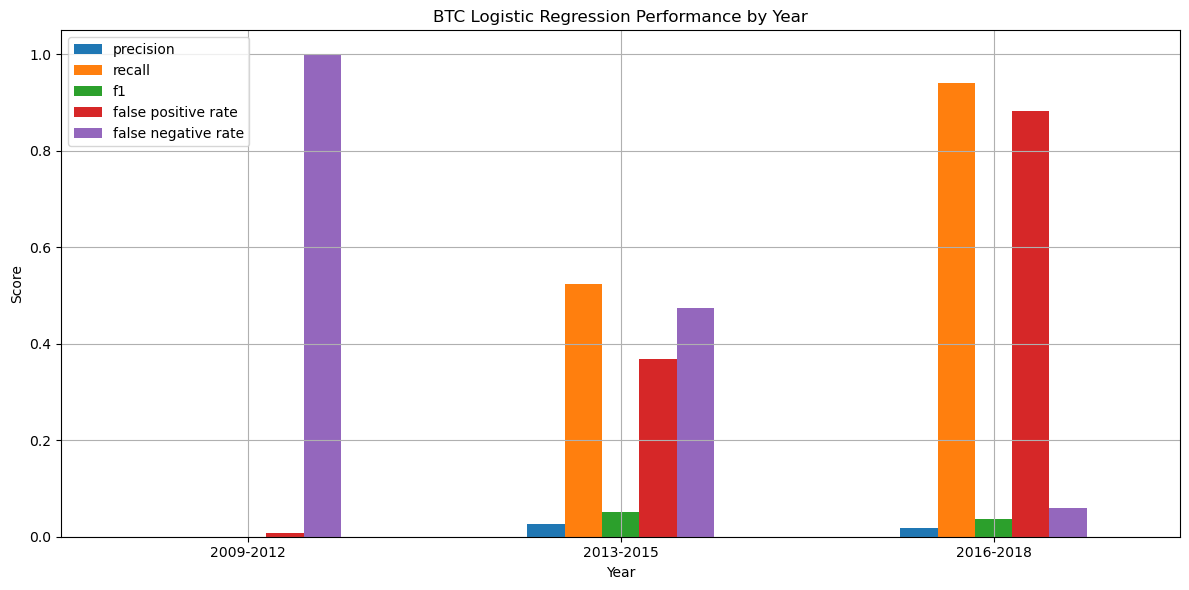

In [43]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(12, 6)

btc_fairness_lr.by_group[["precision", "recall", "f1", "false positive rate", "false negative rate"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("BTC Logistic Regression Performance by Year")
ax.set_ylabel("Score")
ax.set_xlabel("Year")
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()